In [ ]:
from langgraph.graph import END,START,StateGraph
from typing import TypedDict , Literal , Annotated
from langchain_huggingface import ChatHuggingFace ,HuggingFaceEndpoint
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
import operator 

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation")

model = ChatHuggingFace(llm=llm)

In [4]:
class Joke_state(TypedDict):
    topic : str
    joke : str

In [5]:
def create_joke(state:Joke_state):
    topic = state["topic"] 
    prompt = f"crate 5 line joke on {topic}"
    joke = model.invoke(prompt)   
    return {"joke":joke}

In [7]:
graph = StateGraph(Joke_state)


graph.add_node("create_joke",create_joke)

graph.add_edge(START,"create_joke")
graph.add_edge("create_joke",END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

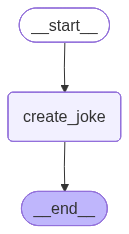

In [8]:
workflow